In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

from XvP_utils.plotting import processing

PROJECT_DIR = Path('/home/mcaskey/10XvParse')

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
TECHS = ['10x', 'polyT', 'randO', 'parse']
COLORS = {
    '10x':   '#4C72B0',
    'polyT': '#DD8452',
    'randO': '#C44E52',
    'parse': '#55A868',
}
TECH_LABELS = {
    '10x':   '10X Genomics',
    'polyT': "Parse 3'",
    'randO': 'Parse Random Oligo',
    'parse': 'Parse (combined)',
}

TISSUE_COLORS = {
    'Cancer':      "#b22104",
    'PBMC':        "#04385E",
    'Thymocytes':  "#6c4801",
    'K562/mESC':   "#49025F",
}

In [4]:
SAMPLES = [
    {
        'label': 'Exp 1',  'analysis': 'Analysis_6',
        'species': 'human', 'tissue': 'Cancer',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
        'malat1_gene': 'MALAT1',
        'cutoffs': {'10x': 1000, 'polyT': 400, 'randO': 400, 'parse': 400},
    },
    {
        'label': 'Exp 2a', 'analysis': 'Analysis_3',
        'species': 'human', 'tissue': 'PBMC',
        'tenx_assay': '10x_H1', 'parse_assay': 'parse_H1',
        'tenx_type': '',
        'malat1_gene': 'MALAT1',
        'cutoffs': {'10x': 600, 'polyT': 900, 'randO': 900, 'parse': 900},
    },
    {
        'label': 'Exp 2b', 'analysis': 'Analysis_3',
        'species': 'human', 'tissue': 'PBMC',
        'tenx_assay': '10x_H2', 'parse_assay': 'parse_H2',
        'tenx_type': '',
        'malat1_gene': 'MALAT1',
        'cutoffs': {'10x': 900, 'polyT': 900, 'randO': 900, 'parse': 900},
    },
    {
        'label': 'Exp 3',  'analysis': 'Analysis_5',
        'species': 'human', 'tissue': 'PBMC',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
        'malat1_gene': 'MALAT1',
        'cutoffs': {'10x': 300, 'polyT': 300, 'randO': 300, 'parse': 300},
    },
    {
        'label': 'Exp 4',  'analysis': 'Analysis_7',
        'species': 'human', 'tissue': 'PBMC',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
        'malat1_gene': 'MALAT1',
        'cutoffs': {'10x': 2000, 'polyT': 900, 'randO': 900, 'parse': 900},
    },
    {
        'label': 'Exp 5a', 'analysis': 'Analysis_2',
        'species': 'mouse', 'tissue': 'Thymocytes',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': 'standard',
        'malat1_gene': 'Malat1',
        'cutoffs': {'10x': 1000, 'polyT': 400, 'randO': 400, 'parse': 400},
    },
    {
        'label': 'Exp 5b', 'analysis': 'Analysis_2',
        'species': 'mouse', 'tissue': 'Thymocytes',
        'tenx_assay': '10x',    'parse_assay': 'parse_mini',
        'tenx_type': 'mini',
        'malat1_gene': 'Malat1',
        'cutoffs': {'10x': 600, 'polyT': 300, 'randO': 300, 'parse': 300},
    },
    {
        'label': 'Exp 6',  'analysis': 'Analysis_4',
        'species': 'human_mouse', 'tissue': 'K562/mESC',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
        'malat1_gene': ['HUMAN_MALAT1', 'MOUSE_Malat1'],
        'cutoffs': {'10x': 1000, 'polyT': 300, 'randO': 300, 'parse': 300},
    },
]

In [5]:
def extract_cell_metrics(adata, malat1_gene):
    genes = malat1_gene if isinstance(malat1_gene, list) else [malat1_gene]
    genes_present = [g for g in genes if g in adata.var_names]
    if genes_present:
        malat1_counts = np.asarray(adata[:, genes_present].X.sum(axis=1)).flatten()
    else:
        malat1_counts = np.zeros(adata.n_obs)
    percent_malat1 = malat1_counts / adata.obs['n_counts'].values * 100

    return pd.DataFrame({
        'percent_nascent': adata.obs['percent_nascent'].values,
        'percent_malat1':  percent_malat1,
        'percent_mito':    adata.obs['percent_mito'].values,
        'percent_ribo':    adata.obs['percent_ribo'].values,
        'percent_lnc':     adata.obs['percent_lnc'].values,
        'percent_pc':      adata.obs['percent_pc'].values,
    })


def read_barcode_stats(star_dir, data_name):
    bc_path = star_dir / f'{data_name}_Solo.out' / 'Barcodes.stats'
    bc_stats = {}
    with open(bc_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                bc_stats[parts[0]] = int(parts[1])
    total = sum(bc_stats.values())
    valid = sum(v for k, v in bc_stats.items() if k.startswith('yes'))
    return bc_stats, valid / total * 100 if total > 0 else 0


def load_sample(sample):
    label    = sample['label']
    analysis = sample['analysis']
    species = sample['species']

    gene_info = pd.read_csv(
        PROJECT_DIR / 'Notebooks' / 'gene_info' / species / 'gene_attributes.csv',
        index_col=0
    )

    dfs, stat_rows, pseudobulk = [], [], {}
    for tech, data_name, assay, use_modified, tenx_type in [
        ('10x',   '10x',   sample['tenx_assay'],  False, sample['tenx_type']),
        ('polyT', 'polyT', sample['parse_assay'], False, ''),
        ('randO', 'randO', sample['parse_assay'], False, ''),
        ('parse', 'parse', sample['parse_assay'], True,  ''),
    ]:
        d = processing.init_processing(
            analysis_name=analysis, project_dir=PROJECT_DIR,
            data_name=data_name, assay=assay,
            data_title=f'{label} {tech}',
            type=tenx_type, modified=use_modified,
        )

        # Bulk-level stats on unfiltered data
        bulk_counts = np.asarray(d.X.sum(axis=0)).flatten()
        expressed = bulk_counts[bulk_counts > 0]
        props = expressed / expressed.sum()
        shannon = -np.sum(props * np.log(props))

        # Alignment stats (from init_processing uns)
        n_proc     = d.uns['n_processed']
        n_aligned  = d.uns['n_aligned']
        star_uniq  = d.uns['star_uniquely_mapped']
        star_multi = d.uns['star_multimapped']
        star_unmap = d.uns['star_unmapped']
        star_total = star_uniq + star_multi + star_unmap

        # Barcode stats from STARsolo
        star_dir = PROJECT_DIR / 'Data' / analysis / assay / 'STARsolo'
        if tenx_type:
            star_dir = star_dir / tenx_type
        bc_stats, pct_valid_bc = read_barcode_stats(star_dir, data_name)

        row = {
            'sample': label,
            'tech':   tech,
            'kallisto_pct_unmapped': (n_proc - n_aligned) / n_proc * 100,
            'star_pct_unmapped':     star_unmap / star_total * 100,
            'star_pct_unique':       star_uniq  / star_total * 100,
            'n_genes_detected':      len(expressed),
            'shannon_entropy':       shannon,
            'star_pct_valid_bc':     pct_valid_bc,
        }
        for cat, count in bc_stats.items():
            row[f'bc_{cat}'] = count
        stat_rows.append(row)

        # Cell-level metrics on filtered data
        d = processing.refilter(d, min_counts=sample['cutoffs'][tech])
        processing.add_cell_metrics(d, gene_info)

        df = extract_cell_metrics(d, sample['malat1_gene'])
        df['label']  = f"{label}\n{tech}"
        df['sample'] = label
        df['tech']   = tech
        dfs.append(df)

        # Pseudobulk log-CPM on filtered data (for correlation heatmaps)
        pb_counts = np.asarray(d.X.sum(axis=0)).flatten()
        pb_cpm = pb_counts / pb_counts.sum() * 1e6
        pseudobulk[tech] = pd.Series(np.log1p(pb_cpm), index=d.var_names)
        del d

    return pd.concat(dfs, ignore_index=True), stat_rows, pseudobulk

In [6]:
all_dfs, all_stats = [], []
pseudobulk_data = {}
for s in SAMPLES:
    print(f"Loading {s['label']}...")
    sample_df, sample_stats, sample_pb = load_sample(s)
    all_dfs.append(sample_df)
    all_stats.extend(sample_stats)
    pseudobulk_data[s['label']] = sample_pb

df = pd.concat(all_dfs, ignore_index=True)
stats_df = pd.DataFrame(all_stats)
print(f"Total cells: {len(df)}")

Loading Exp 1...


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Loading Exp 2a...


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Loading Exp 2b...


...

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Loading Exp 6...


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Total cells: 388520


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


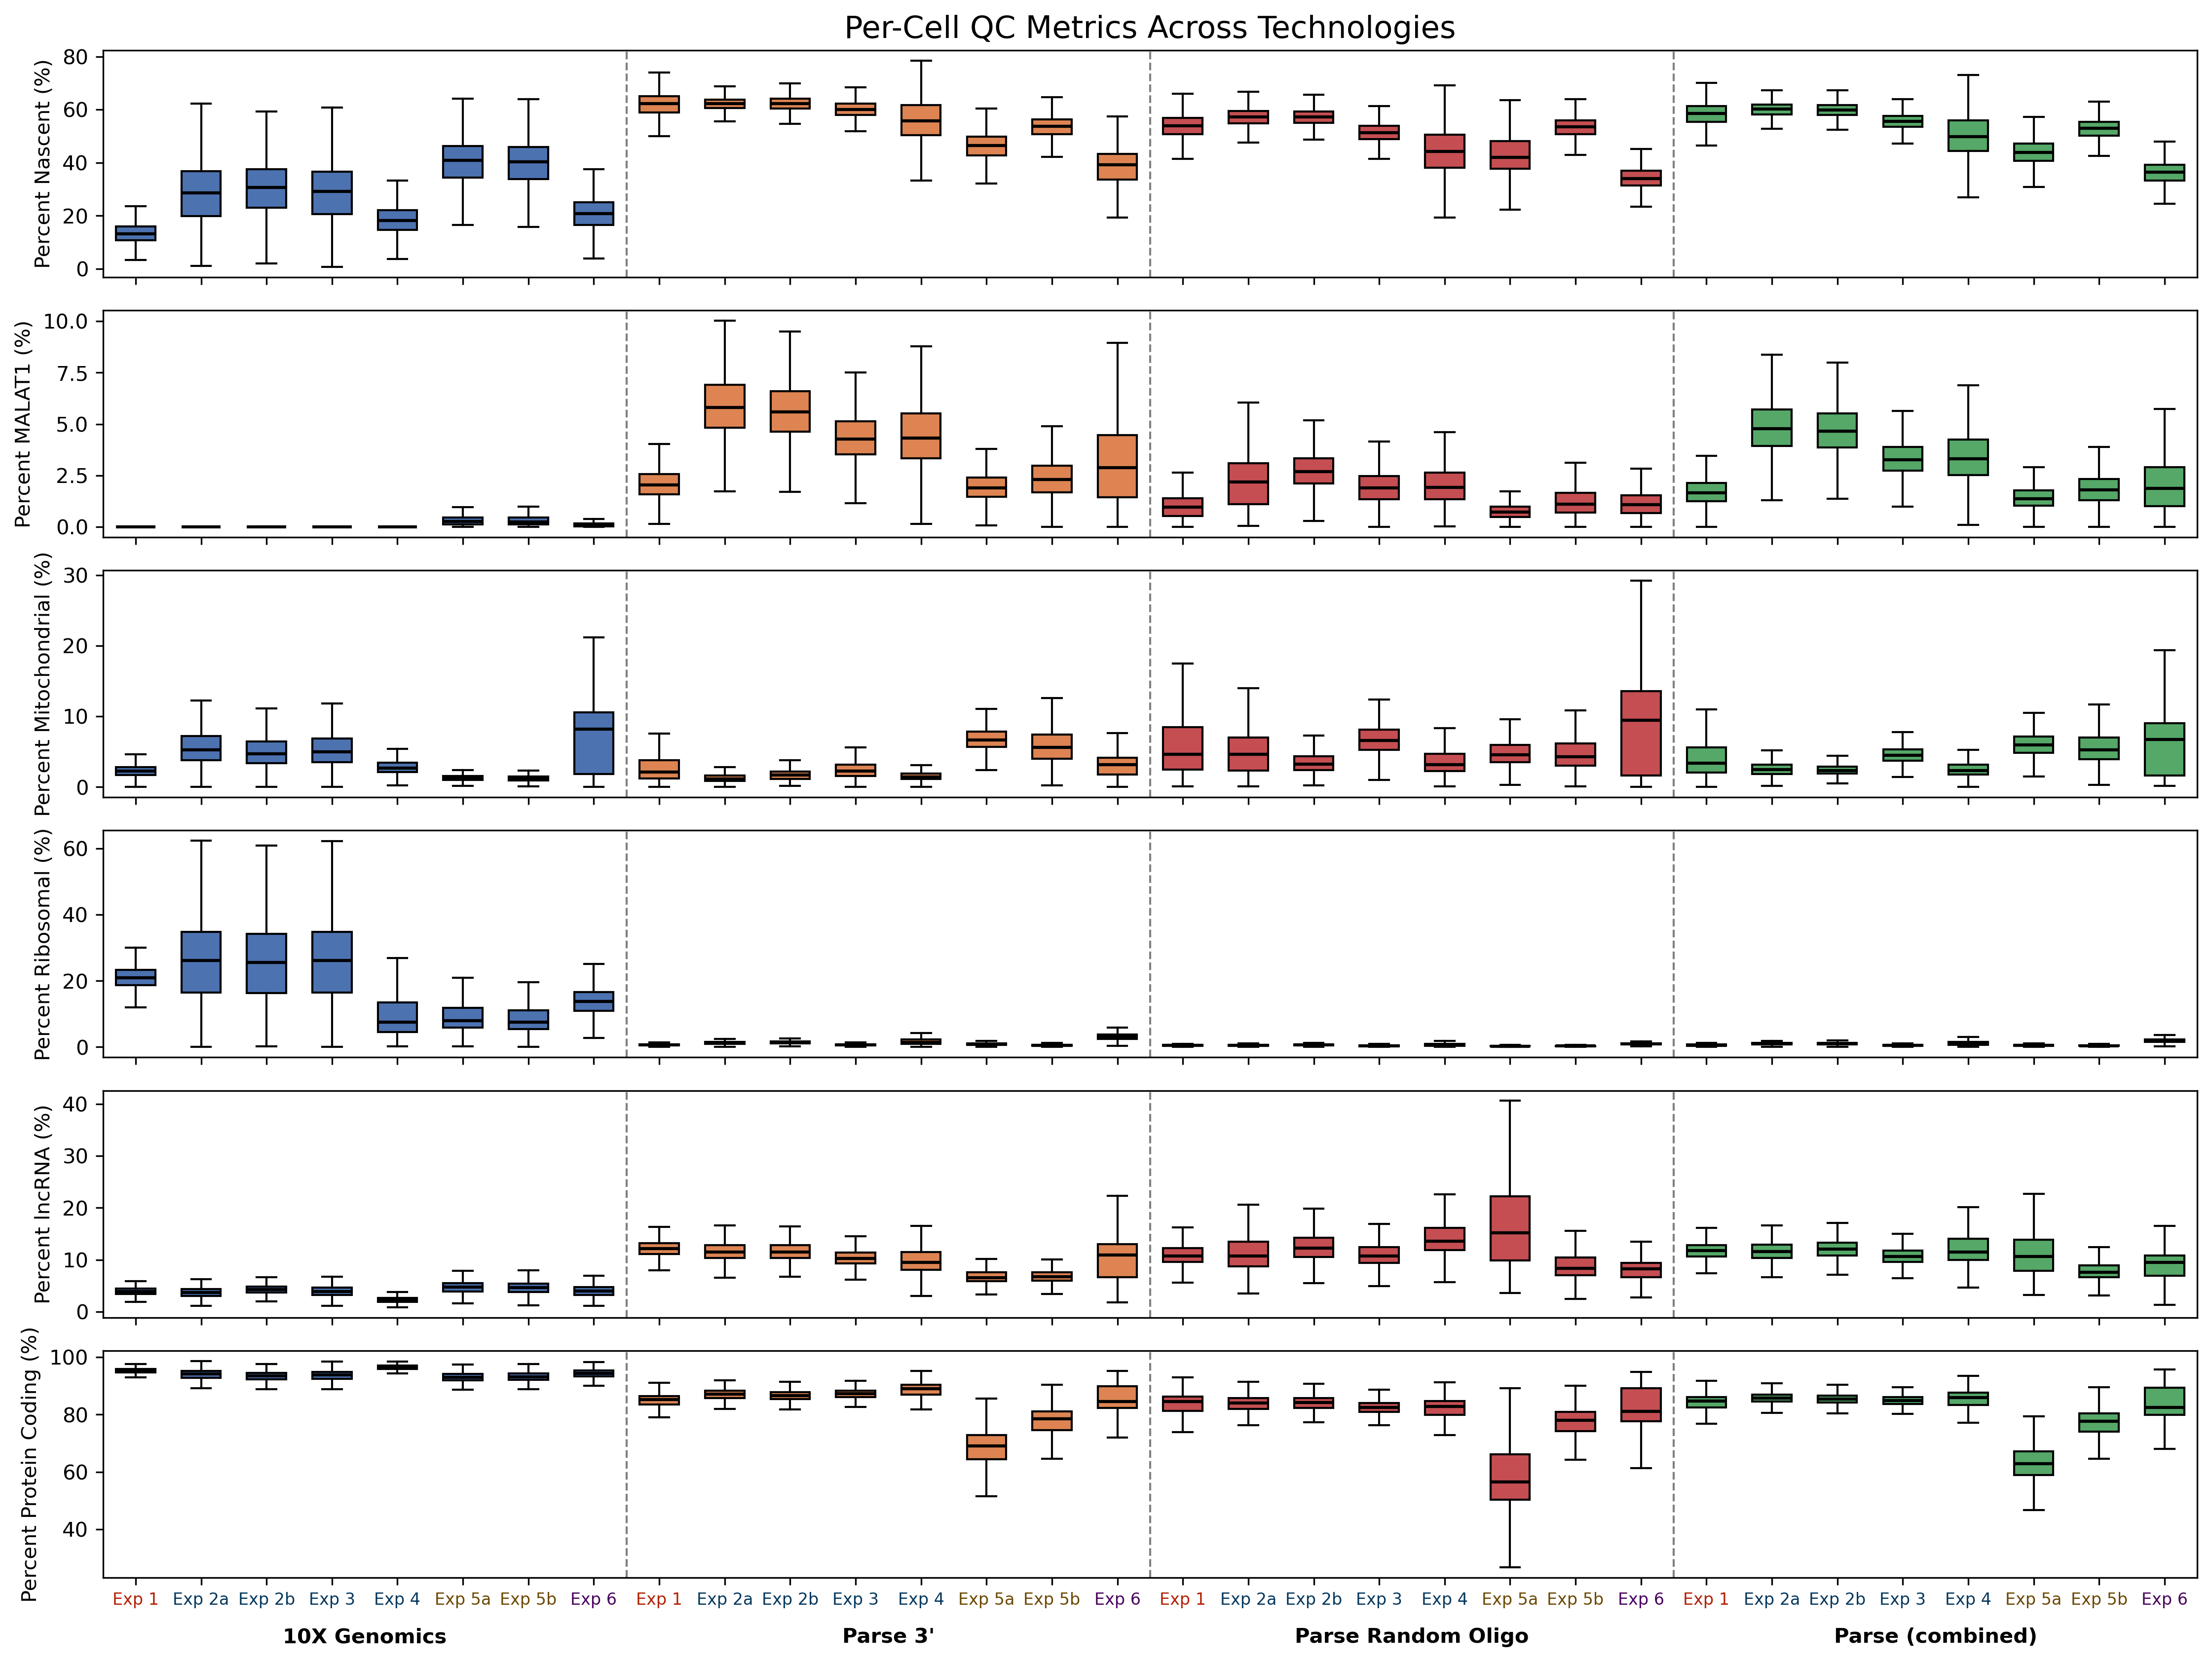

In [7]:
METRICS = [
    ('percent_nascent', 'Percent Nascent (%)'),
    ('percent_malat1',  'Percent MALAT1 (%)'),
    ('percent_mito',    'Percent Mitochondrial (%)'),
    ('percent_ribo',    'Percent Ribosomal (%)'),
    ('percent_lnc',     'Percent lncRNA (%)'),
    ('percent_pc',      'Percent Protein Coding (%)'),
]

# Group by technology: all samples for each tech together, 10x leftmost
n_samples = len(SAMPLES)
x_order = [f"{s['label']}\n{tech}" for tech in TECHS for s in SAMPLES]
display_labels = [s['label'] for tech in TECHS for s in SAMPLES]

fig, axes = plt.subplots(len(METRICS), 1, figsize=(15, 2 * len(METRICS)), sharex=True, dpi=300)

for ax, (metric, ylabel) in zip(axes, METRICS):
    data_by_label = [df.loc[df['label'] == lbl, metric].dropna().values for lbl in x_order]
    bp = ax.boxplot(
        data_by_label,
        positions=range(len(x_order)),
        patch_artist=True,
        showfliers=False,
        widths=0.6,
        medianprops=dict(color='black', linewidth=1.5),
    )
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(COLORS[TECHS[i // n_samples]])

    for t in range(1, len(TECHS)):
        ax.axvline(x=t * n_samples - 0.5, color='gray', linestyle='--', linewidth=1)

    ax.set_ylabel(ylabel)

# Experiment name tick labels (no tech)
axes[-1].set_xticks(range(len(x_order)))
axes[-1].set_xticklabels(display_labels, fontsize=8)
for tick_idx, tick in enumerate(axes[-1].get_xticklabels()):
    tick.set_color(TISSUE_COLORS[SAMPLES[tick_idx % n_samples]['tissue']])

# Centered technology group labels below the tick labels
for t_idx, tech in enumerate(TECHS):
    center = t_idx * n_samples + (n_samples - 1) / 2
    axes[-1].text(center, -0.22, TECH_LABELS[tech], ha='center', va='top',
                  fontsize=10, fontweight='bold', color='black',
                  transform=axes[-1].get_xaxis_transform())

legend_handles = [mpatches.Patch(color=COLORS[t], label=TECH_LABELS[t]) for t in TECHS]
axes[0].set_title('Per-Cell QC Metrics Across Technologies', fontsize=15)

fig.subplots_adjust(bottom=0.12)
fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [8]:
rows = []
for tech in TECHS:
    for s in SAMPLES:
        lbl = f"{s['label']}\n{tech}"
        subset = df[df['label'] == lbl]
        for metric, metric_label in METRICS:
            vals = subset[metric].dropna()
            rows.append({
                'Experiment': s['label'],
                'Technology': TECH_LABELS[tech],
                'Metric': metric_label,
                'Mean': vals.mean(),
                'Min': vals.min(),
                'Max': vals.max(),
            })

summary_df = pd.DataFrame(rows)

for metric_label in summary_df['Metric'].unique():
    sub = summary_df[summary_df['Metric'] == metric_label].copy()
    sub = sub.drop(columns='Metric').set_index(['Experiment', 'Technology'])
    print(f"--- {metric_label} ---")
    display(sub.style.format({'Mean': '{:.2f}', 'Min': '{:.2f}', 'Max': '{:.2f}'}))

--- Percent Nascent (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,13.81,0.87,66.00
Exp 2a,10X Genomics,28.84,1.02,79.30
Exp 2b,10X Genomics,30.67,1.99,82.07
Exp 3,10X Genomics,29.13,0.74,80.76
Exp 4,10X Genomics,18.97,0.65,77.76
Exp 5a,10X Genomics,40.70,1.96,77.30
Exp 5b,10X Genomics,40.43,1.54,78.54
Exp 6,10X Genomics,20.84,0.92,84.04
Exp 1,Parse 3',59.11,12.91,81.46


--- Percent MALAT1 (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,0.00,0.00,0.12
Exp 2a,10X Genomics,0.01,0.00,0.19
Exp 2b,10X Genomics,0.01,0.00,0.21
Exp 3,10X Genomics,0.01,0.00,0.54
Exp 4,10X Genomics,0.00,0.00,0.11
Exp 5a,10X Genomics,0.33,0.00,2.53
Exp 5b,10X Genomics,0.33,0.00,2.60
Exp 6,10X Genomics,0.13,0.00,1.25
Exp 1,Parse 3',2.13,0.00,12.96


--- Percent Mitochondrial (%) ---


...

,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,21.03,1.57,39.15
Exp 2a,10X Genomics,25.96,0.00,65.92
Exp 2b,10X Genomics,25.49,0.16,63.08
Exp 3,10X Genomics,25.85,0.00,76.00
Exp 4,10X Genomics,9.11,0.28,34.03
Exp 5a,10X Genomics,9.23,0.16,40.38
Exp 5b,10X Genomics,8.67,0.14,37.43
Exp 6,10X Genomics,13.88,0.28,32.71
Exp 1,Parse 3',0.77,0.00,8.25


--- Percent lncRNA (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,3.99,1.13,16.91
Exp 2a,10X Genomics,3.81,0.18,18.32
Exp 2b,10X Genomics,4.37,0.61,17.10
Exp 3,10X Genomics,4.03,0.00,19.81
Exp 4,10X Genomics,2.41,0.65,11.15
Exp 5a,10X Genomics,4.75,0.90,15.34
Exp 5b,10X Genomics,4.63,0.77,15.47
Exp 6,10X Genomics,4.04,1.03,10.19
Exp 1,Parse 3',12.08,2.42,25.92


--- Percent Protein Coding (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,95.16,58.14,98.62
Exp 2a,10X Genomics,93.33,25.92,99.34
Exp 2b,10X Genomics,92.84,43.81,97.90
Exp 3,10X Genomics,93.06,25.68,99.40
Exp 4,10X Genomics,96.27,43.00,99.07
Exp 5a,10X Genomics,93.01,72.92,98.77
Exp 5b,10X Genomics,93.13,70.48,98.90
Exp 6,10X Genomics,94.22,78.70,98.29
Exp 1,Parse 3',82.82,31.48,92.84


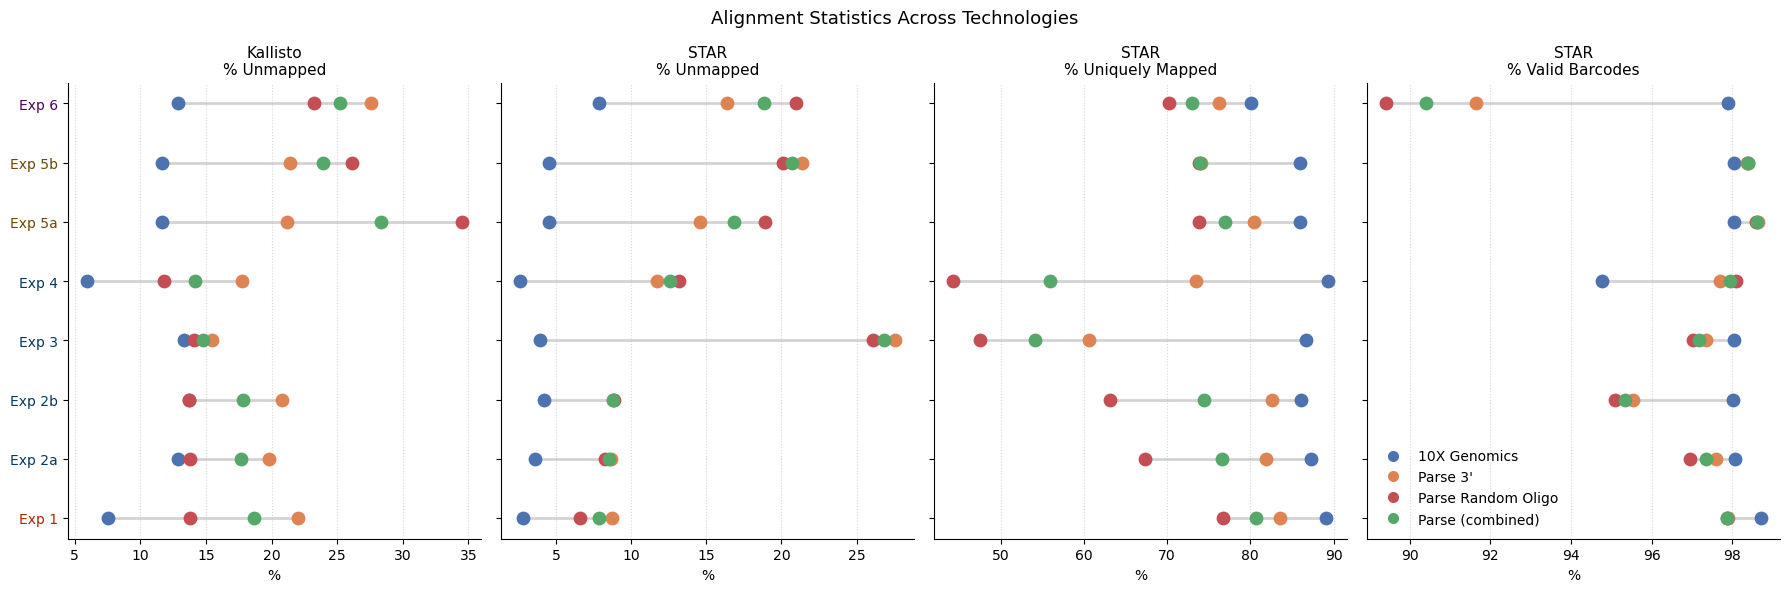

In [9]:
STAT_METRICS = [
    ('kallisto_pct_unmapped', 'Kallisto\n% Unmapped'),
    ('star_pct_unmapped',     'STAR\n% Unmapped'),
    ('star_pct_unique',       'STAR\n% Uniquely Mapped'),
    ('star_pct_valid_bc',     'STAR\n% Valid Barcodes'),
]

sample_labels = [s['label'] for s in SAMPLES]

fig, axes = plt.subplots(1, len(STAT_METRICS), figsize=(18, max(4, len(sample_labels) * 0.75)), sharey=True)

for ax, (metric, title) in zip(axes, STAT_METRICS):
    for y, lbl in enumerate(sample_labels):
        sub  = stats_df[stats_df['sample'] == lbl]
        vals = {tech: sub.loc[sub['tech'] == tech, metric].values[0] for tech in TECHS}

        ax.plot([min(vals.values()), max(vals.values())], [y, y],
                color='lightgray', linewidth=2, zorder=1)
        for tech, val in vals.items():
            ax.scatter([val], [y], color=COLORS[tech], s=80, zorder=2)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('%')
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_yticks(range(len(sample_labels)))
axes[0].set_yticklabels(sample_labels)
for i, tick in enumerate(axes[0].get_yticklabels()):
    tick.set_color(TISSUE_COLORS[SAMPLES[i]['tissue']])

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS[t],
               markersize=9, label=TECH_LABELS[t])
    for t in TECHS
]
axes[-1].legend(handles=legend_handles, loc='lower left', frameon=False)

fig.suptitle('Alignment Statistics Across Technologies', fontsize=13)
fig.tight_layout()
plt.show()

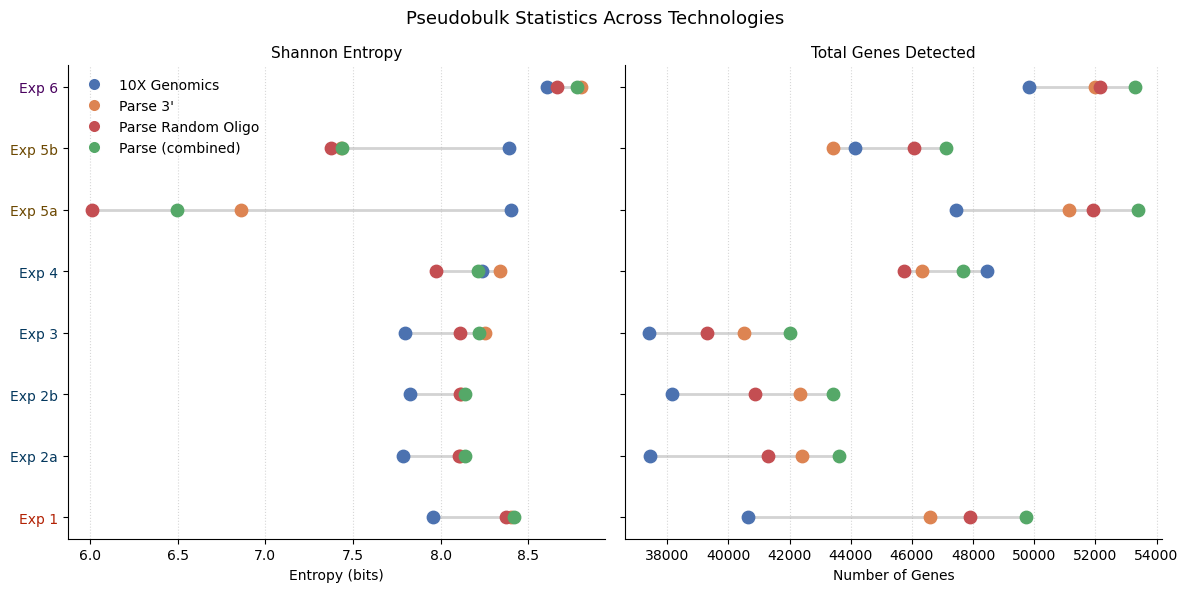

In [10]:
BULK_METRICS = [
    ('shannon_entropy',  'Shannon Entropy'),
    ('n_genes_detected', 'Total Genes Detected'),
]

sample_labels = [s['label'] for s in SAMPLES]

fig, axes = plt.subplots(1, len(BULK_METRICS), figsize=(12, max(4, len(sample_labels) * 0.75)), sharey=True)

for ax, (metric, title) in zip(axes, BULK_METRICS):
    for y, lbl in enumerate(sample_labels):
        sub  = stats_df[stats_df['sample'] == lbl]
        vals = {tech: sub.loc[sub['tech'] == tech, metric].values[0] for tech in TECHS}

        ax.plot([min(vals.values()), max(vals.values())], [y, y],
                color='lightgray', linewidth=2, zorder=1)
        for tech, val in vals.items():
            ax.scatter([val], [y], color=COLORS[tech], s=80, zorder=2)

    ax.set_title(title, fontsize=11)
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_yticks(range(len(sample_labels)))
axes[0].set_yticklabels(sample_labels)
for i, tick in enumerate(axes[0].get_yticklabels()):
    tick.set_color(TISSUE_COLORS[SAMPLES[i]['tissue']])

axes[0].set_xlabel("Entropy (bits)")
axes[1].set_xlabel("Number of Genes")

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS[t],
               markersize=9, label=TECH_LABELS[t])
    for t in TECHS
]
axes[0].legend(handles=legend_handles, loc='upper left', frameon=False)

fig.suptitle('Pseudobulk Statistics Across Technologies', fontsize=13)
fig.tight_layout()
plt.show()

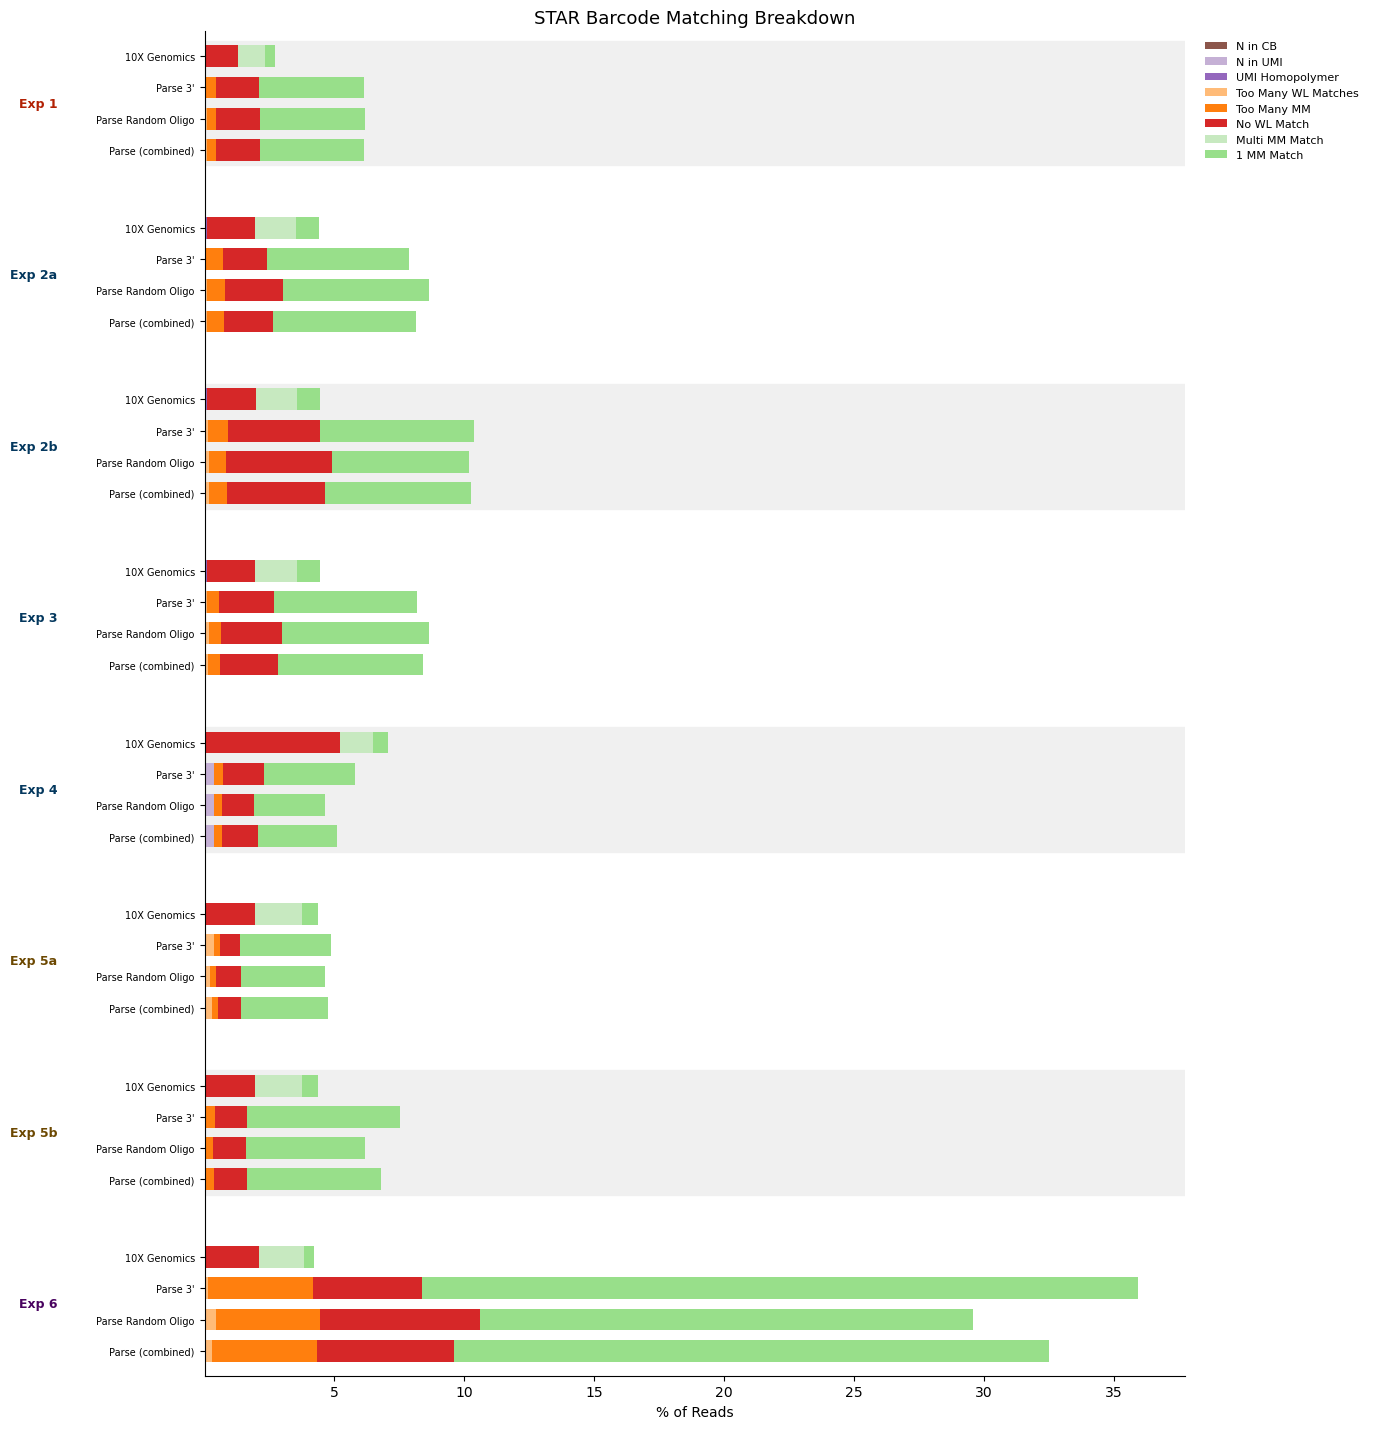

In [11]:
BC_CATEGORIES = [
    ('bc_yesWLmatchExact',      'Exact Match',           '#2ca02c'),
    ('bc_yesOneWLmatchWithMM',  '1 MM Match',            '#98df8a'),
    ('bc_yesMultWLmatchWithMM', 'Multi MM Match',        '#c7e9c0'),
    ('bc_noNoWLmatch',          'No WL Match',           '#d62728'),
    ('bc_noTooManyMM',          'Too Many MM',           '#ff7f0e'),
    ('bc_noTooManyWLmatches',   'Too Many WL Matches',   '#ffbb78'),
    ('bc_noUMIhomopolymer',     'UMI Homopolymer',       '#9467bd'),
    ('bc_noNinUMI',             'N in UMI',              '#c5b0d5'),
    ('bc_noNinCB',              'N in CB',               '#8c564b'),
    ('bc_noNoCB',               'No CB',                 '#bcbd22'),
    ('bc_noNoUMI',              'No UMI',                '#17becf'),
    ('bc_noNoAdapter',          'No Adapter',            '#7f7f7f'),
]

BC_CATEGORIES=BC_CATEGORIES[::-1]

sample_labels = [s['label'] for s in SAMPLES]
n_techs = len(TECHS)
gap = 1.5

# Bar positions with gaps between sample groups
positions = []
tick_labels = []
for s_idx, lbl in enumerate(sample_labels):
    for t_idx, tech in enumerate(TECHS):
        positions.append(s_idx * (n_techs + gap) + t_idx)
        tick_labels.append(TECH_LABELS[tech])

# Compute proportions per bar
proportions = np.zeros((len(positions), len(BC_CATEGORIES)))
for i, (lbl, tech) in enumerate([(l, t) for l in sample_labels for t in TECHS]):
    row = stats_df[(stats_df['sample'] == lbl) & (stats_df['tech'] == tech)].iloc[0]
    counts = np.array([row.get(col, 0) for col, _, _ in BC_CATEGORIES], dtype=float)
    total = counts.sum()
    if total > 0:
        proportions[i] = counts / total * 100

fig, ax = plt.subplots(figsize=(14, max(6, len(positions) * 0.45)))

# Alternating background bands per sample group
for s_idx, lbl in enumerate(sample_labels):
    y_top = s_idx * (n_techs + gap) - 0.5
    y_bot = y_top + n_techs
    if s_idx % 2 == 0:
        ax.axhspan(y_top, y_bot, color='#f0f0f0', zorder=0)
    y_mid = y_top + n_techs / 2
    ax.text(-0.15, y_mid, lbl, ha='right', va='center', fontsize=9, fontweight='bold',
            color=TISSUE_COLORS[SAMPLES[s_idx]['tissue']],
            transform=ax.get_yaxis_transform())

lefts = np.zeros(len(positions))
for j, (col, label, color) in enumerate(BC_CATEGORIES):
    if j == len(BC_CATEGORIES)-1:
        continue
    vals = proportions[:, j]
    if vals.sum() == 0:
        continue
    ax.barh(positions, vals, left=lefts, height=0.7, label=label, color=color)
    lefts += vals

ax.set_yticks(positions)
ax.set_yticklabels(tick_labels, fontsize=7)
ax.set_xlabel('% of Reads')
ax.set_ylim(max(positions) + 0.8, min(positions) - 0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
ax.set_title('STAR Barcode Matching Breakdown', fontsize=13)

fig.tight_layout()
plt.show()

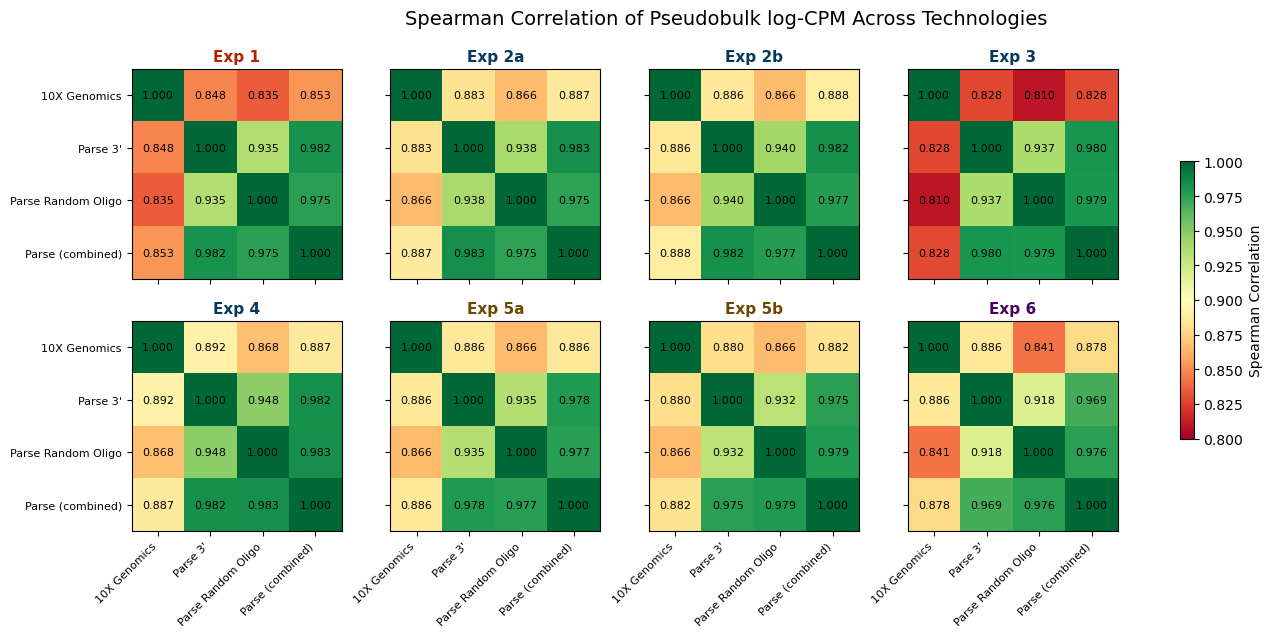

In [12]:
from scipy.stats import spearmanr

# Options: 'pearson', 'spearman', 'ccc'
CORR_METHOD = 'spearman'

def compute_correlation(x, y, method):
    if method == 'pearson':
        return np.corrcoef(x, y)[0, 1]
    elif method == 'spearman':
        return spearmanr(x, y).correlation
    elif method == 'ccc':
        mean_x, mean_y = np.mean(x), np.mean(y)
        var_x, var_y = np.var(x), np.var(y)
        r = np.corrcoef(x, y)[0, 1]
        return 2 * r * np.sqrt(var_x) * np.sqrt(var_y) / (var_x + var_y + (mean_x - mean_y)**2)

# Compute all correlation matrices
corr_matrices = {}
for s in SAMPLES:
    pb = pseudobulk_data[s['label']]
    common_genes = sorted(set.intersection(*[set(pb[t].index) for t in TECHS]))
    matrix = np.ones((len(TECHS), len(TECHS)))
    for i, t1 in enumerate(TECHS):
        for j, t2 in enumerate(TECHS):
            if i != j:
                x = pb[t1].loc[common_genes].values
                y = pb[t2].loc[common_genes].values
                matrix[i, j] = compute_correlation(x, y, CORR_METHOD)
    corr_matrices[s['label']] = matrix

# Global color scale
all_off_diag = [m[i, j] for m in corr_matrices.values() for i in range(4) for j in range(4) if i != j]
vmin = np.floor(min(all_off_diag) * 20) / 20

n_cols = 4
n_rows = (len(SAMPLES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.atleast_2d(axes)

for idx, s in enumerate(SAMPLES):
    ax = axes[idx // n_cols, idx % n_cols]
    matrix = corr_matrices[s['label']]

    im = ax.imshow(matrix, vmin=vmin, vmax=1.0, cmap='RdYlGn', aspect='equal')

    ax.set_xticks(range(len(TECHS)))
    ax.set_yticks(range(len(TECHS)))
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.set_title(s['label'], fontsize=11, fontweight='bold',
                 color=TISSUE_COLORS[s['tissue']])

    if idx // n_cols == n_rows - 1 or idx == len(SAMPLES) - 1:
        ax.set_xticklabels(TECH_LABELS.values(), fontsize=8, rotation=45, ha='right')

    for i in range(len(TECHS)):
        for j in range(len(TECHS)):
            ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center', fontsize=8,
                    color='black')

for i in range(n_rows):
    axes[i, 0].set_yticks(range(len(TECHS)))
    axes[i, 0].set_yticklabels(TECH_LABELS.values(), fontsize=8)

for idx in range(len(SAMPLES), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.colorbar(im, ax=axes, shrink=0.6, label=f'{CORR_METHOD.capitalize()} Correlation')
fig.suptitle(f'{CORR_METHOD.capitalize()} Correlation of Pseudobulk log-CPM Across Technologies', fontsize=14)
plt.show()